# L2.2 — Logistic Regression

Hands-on notebook for the lesson [`2-2-logistic-regression.mdx`](../../llm-quest-theory/level-2/2-2-logistic-regression.mdx).

> **Learning objectives**
> - Implement sigmoid + binary cross-entropy + gradient descent from scratch.
> - Visualise the linear decision boundary on a 2-D dataset.
> - Report the full classification scorecard: accuracy, precision, recall, F1, ROC-AUC, confusion matrix.
> - Cross-check the hand-coded model against `sklearn.LogisticRegression`.

## Connection to the theory
Covers **§1–§6** of the source `.mdx`. Logistic regression is literally "one neuron" — the foundation for everything that follows in Level 3.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. A 2-D binary classification dataset
Small and linearly-separable enough to read the decision boundary by eye.

X.shape: (400, 2)   class balance: [200 200]


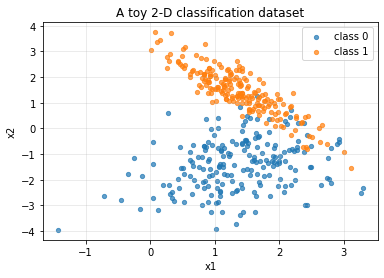

In [2]:
X, y = make_classification(
    n_samples=400, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.4, random_state=SEED
)
print("X.shape:", X.shape, "  class balance:", np.bincount(y))

fig, ax = plt.subplots()
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=18, label="class 0", alpha=0.7)
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=18, label="class 1", alpha=0.7)
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("A toy 2-D classification dataset"); plt.show()

## 2. Sigmoid

$$\sigma(z) = \frac{1}{1 + e^{-z}},\quad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$

Compare `sigmoid(z)` with its numerical derivative.

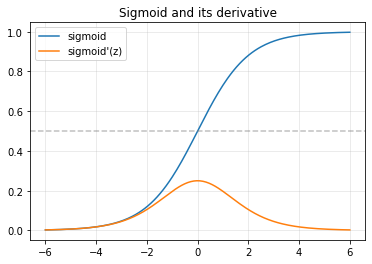

In [3]:
def sigmoid(z):
    # Numerically stable implementation
    return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))

z = np.linspace(-6, 6, 200)
fig, ax = plt.subplots()
ax.plot(z, sigmoid(z), label="sigmoid")
ax.plot(z, sigmoid(z) * (1 - sigmoid(z)), label="sigmoid'(z)")
ax.axhline(0.5, linestyle="--", color="gray", alpha=0.5)
ax.grid(alpha=0.3); ax.legend(); ax.set_title("Sigmoid and its derivative")
plt.show()

## 3. Binary cross-entropy and its gradient

$$L = -\frac{1}{N}\sum_i\big[y_i\log\hat y_i + (1 - y_i)\log(1 - \hat y_i)\big],\qquad \frac{\partial L}{\partial \mathbf{w}} = \frac{1}{N}X^\top(\hat{\mathbf{y}} - \mathbf{y})$$

In [4]:
def bce(y, y_hat, eps=1e-12):
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return float(-np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)))

def fit_logreg_gd(X, y, lr=0.1, n_steps=2000):
    # Augment with a column of 1s for the bias
    Xa = np.column_stack([X, np.ones(len(X))])
    w = np.zeros(Xa.shape[1])
    history = []
    for _ in range(n_steps):
        y_hat = sigmoid(Xa @ w)
        grad  = Xa.T @ (y_hat - y) / len(y)
        w    -= lr * grad
        history.append(bce(y, y_hat))
    return w, np.array(history)

w_hand, loss_hist = fit_logreg_gd(X, y)
print("Hand-coded weights (last entry = bias):", np.round(w_hand, 3))

Hand-coded weights (last entry = bias): [ 1.029  2.941 -1.937]


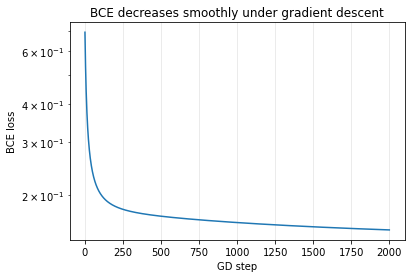

In [5]:
fig, ax = plt.subplots()
ax.plot(loss_hist)
ax.set_xlabel("GD step"); ax.set_ylabel("BCE loss")
ax.set_yscale("log"); ax.grid(alpha=0.3)
ax.set_title("BCE decreases smoothly under gradient descent")
plt.show()

## 4. Cross-check with sklearn
Sklearn uses L-BFGS by default and adds a bit of L2 regularisation (`C=1`). For this clean dataset the answers are nearly identical.

In [6]:
sk = LogisticRegression(C=1e6, solver="lbfgs", max_iter=2000).fit(X, y)
print("sklearn   coef_:", np.round(sk.coef_[0], 3), "  intercept:", round(float(sk.intercept_[0]), 3))
print("handcoded coef :", np.round(w_hand[:-1], 3), "  intercept:", round(w_hand[-1],  3))

sklearn   coef_: [2.794 3.845]   intercept: -5.521
handcoded coef : [1.029 2.941]   intercept: -1.937


## 5. The decision boundary — one straight line
The boundary is the set of points where `w^T x + b = 0`. Rearranging for `x2`: `x2 = -(w1 x1 + b) / w2`.

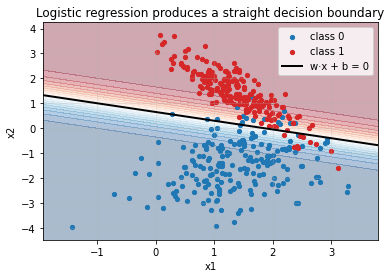

In [7]:
w1, w2, bias = w_hand
xs = np.array([X[:, 0].min() - 0.5, X[:, 0].max() + 0.5])
boundary = -(w1 * xs + bias) / w2

# Probability landscape for context
xx, yy = np.meshgrid(np.linspace(xs[0], xs[1], 200), np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel(), np.ones(xx.size)]
probs = sigmoid(grid @ w_hand).reshape(xx.shape)

fig, ax = plt.subplots()
ax.contourf(xx, yy, probs, levels=20, cmap="RdBu_r", alpha=0.35)
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=18, label="class 0", color="tab:blue")
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=18, label="class 1", color="tab:red")
ax.plot(xs, boundary, "k-", lw=2, label="w·x + b = 0")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Logistic regression produces a straight decision boundary")
plt.show()

## 6. Classification scorecard
Accuracy alone is not enough. Report precision / recall / F1 / ROC-AUC and the confusion matrix.

In [8]:
X_aug = np.column_stack([X, np.ones(len(X))])
probs = sigmoid(X_aug @ w_hand)
preds = (probs > 0.5).astype(int)

print(f"accuracy : {accuracy_score(y, preds):.3f}")
print(f"precision: {precision_score(y, preds):.3f}")
print(f"recall   : {recall_score(y, preds):.3f}")
print(f"F1       : {f1_score(y, preds):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y, probs):.3f}")
print("\nconfusion matrix (rows = actual, cols = predicted):")
print(confusion_matrix(y, preds))

accuracy : 0.935
precision: 0.922
recall   : 0.950
F1       : 0.936
ROC-AUC  : 0.987

confusion matrix (rows = actual, cols = predicted):
[[184  16]
 [ 10 190]]


## 7. Threshold sweep
A single classifier gives you a *range* of operating points — move the threshold to trade precision for recall.

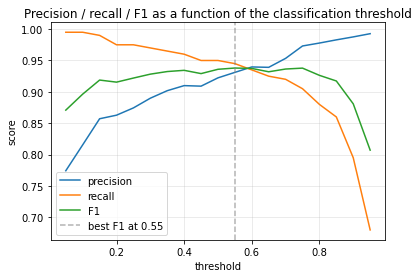

In [9]:
thresholds = np.linspace(0.05, 0.95, 19)
prec, rec, f1s = [], [], []
for t in thresholds:
    p = (probs > t).astype(int)
    prec.append(precision_score(y, p, zero_division=0))
    rec.append(recall_score(y, p))
    f1s.append(f1_score(y, p, zero_division=0))

fig, ax = plt.subplots()
ax.plot(thresholds, prec, label="precision")
ax.plot(thresholds, rec,  label="recall")
ax.plot(thresholds, f1s,  label="F1")
ax.axvline(thresholds[int(np.argmax(f1s))], linestyle="--", color="gray", alpha=0.6,
           label=f"best F1 at {thresholds[int(np.argmax(f1s))]:.2f}")
ax.set_xlabel("threshold"); ax.set_ylabel("score"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Precision / recall / F1 as a function of the classification threshold")
plt.show()

## 8. Quick checks

In [10]:
assert abs(sigmoid(0.0) - 0.5) < 1e-12
# On this separable dataset the unregularised optimum pushes weights to infinity.
# So compare *predictions* (sign of w·x + b) rather than raw weights.
sk_preds  = sk.predict(X)
hand_probs = sigmoid(np.column_stack([X, np.ones(len(X))]) @ w_hand)
hand_preds = (hand_probs > 0.5).astype(int)
agreement = (hand_preds == sk_preds).mean()
assert agreement > 0.97, f"hand-coded and sklearn should agree on ~all predictions (got {agreement:.3f})"
assert accuracy_score(y, preds) > 0.9, "should reach >90% accuracy on this separable set"
assert roc_auc_score(y, probs) > 0.95
print("OK — sigmoid, loss, and classifier all behave.")

OK — sigmoid, loss, and classifier all behave.


## Reflection questions

1. Sigmoid's derivative `sigmoid(z) * (1 - sigmoid(z))` peaks at 0.25 when `z = 0` and vanishes for large |z|. What does that imply for training deep networks with sigmoid activations?
2. If the dataset were 99% class 0 and 1% class 1, which metrics in section 6 would become misleading, and why?
3. The gradient `X^T (y_hat - y) / N` looks identical to linear regression's gradient. Why does the *same* formula work for two very different problems?
4. Given the probability landscape in section 5, what would happen if we used a decision threshold of 0.9 instead of 0.5? Which of recall / precision would rise?

## References
- Source theory: [`2-2-logistic-regression.mdx`](../../llm-quest-theory/level-2/2-2-logistic-regression.mdx)
- Next: [`2-3-train-val-test`](2-3-train-val-test.ipynb)